Name: Boga Petruska and Bence Szabo\
Class: ECBS5171 - Data Analysis 3\
Assignment: Assignment 2 - Fast Growth Prediction\
Date: Feb 15, 2026

Modeling Notebook

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix, 
    brier_score_loss, mean_squared_error
)

sns.set_theme(style="whitegrid")
random_seed = 42

## Task 1

### PART I: Probability prediction

In [28]:
# load prepped data

csv_path = "../data/prepped/bisnode_firms_prepped.csv"
data = pd.read_csv(csv_path)

print(f"Loaded: {data.shape[0]:,} rows, {data.shape[1]} columns")
print(f"Fast-growth rate: {data['fast_growth'].mean():.1%}")

Loaded: 15,220 rows, 89 columns
Fast-growth rate: 28.8%


In [29]:
# interaction terms
interactions = [
    ("ind2_cat", "age"), ("ind2_cat", "age2"),
    ("ind2_cat", "sales_mil_log"), ("ind2_cat", "ceo_age"),
    ("ind2_cat", "foreign_management"),
    ("sales_mil_log", "age"), ("sales_mil_log", "profit_loss_year_pl"),
    ("sales_mil_log", "foreign_management"),
]

for var1, var2 in interactions:
    col_name = f"{var1}*{var2}"
    data[col_name] = data[var1] * data[var2]

print(f"Interaction terms created: {len(interactions)}")

Interaction terms created: 8


In [30]:
# organize variable lists for modeling
rawvars = ["curr_assets", "curr_liab", "extra_exp", "extra_inc", 
           "extra_profit_loss", "fixed_assets", "inc_bef_tax", 
           "intang_assets", "inventories", "liq_assets", "material_exp",
           "personnel_exp", "profit_loss_year", "sales", "share_eq", 
           "subscribed_cap"]

qualityvars = ["balsheet_flag", "balsheet_length", "balsheet_notfullyear"]

engvar = ["total_assets_bs", "fixed_assets_bs", "liq_assets_bs", 
          "curr_assets_bs", "share_eq_bs", "subscribed_cap_bs",
          "intang_assets_bs", "extra_exp_pl", "extra_inc_pl",
          "extra_profit_loss_pl", "inc_bef_tax_pl", "inventories_pl",
          "material_exp_pl", "profit_loss_year_pl", "personnel_exp_pl"]

engvar2 = ["extra_profit_loss_pl_quad", "inc_bef_tax_pl_quad",
           "profit_loss_year_pl_quad", "share_eq_bs_quad"]

# Collect all flag variables dynamically
engvar3 = [col for col in data.columns 
           if col.endswith(("flag_low", "flag_high", "flag_zero"))]

hr = ["female", "ceo_age", "flag_high_ceo_age", "flag_low_ceo_age",
      "flag_miss_ceo_age", "ceo_count", "foreign_management"]

firm = ["age", "age2", "new", "ind2_cat", "manufacturing_flg", 
        "services_flg", "urban_m"]

interactions_list = [f"{v1}*{v2}" for v1, v2 in interactions]

print(f"Variable counts:")
print(f"  Raw: {len(rawvars)}, Quality: {len(qualityvars)}")
print(f"  Engineered: {len(engvar)}, Squared: {len(engvar2)}")
print(f"  Flags: {len(engvar3)}, HR: {len(hr)}, Firm: {len(firm)}")
print(f"  Interactions: {len(interactions_list)}")
print(f"  Total features: {len(rawvars + qualityvars + engvar + engvar2 + engvar3 + hr + firm + interactions_list)}")

Variable counts:
  Raw: 16, Quality: 3
  Engineered: 15, Squared: 4
  Flags: 12, HR: 7, Firm: 7
  Interactions: 8
  Total features: 72


In [31]:
# Train / Holdout split
data_train, data_holdout = train_test_split(
    data, test_size=0.2, random_state=random_seed, stratify=data["fast_growth"]
)

y_train = data_train["fast_growth"].astype(int)
y_holdout = data_holdout["fast_growth"].astype(int)

# configure cross-validation
k = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

# no regularisation needed so setting the parameter to very high value
Cs_value_logit = [1e20]

print(f"Train: {len(data_train):,}  |  Holdout: {len(data_holdout):,}")
print(f"Train fast-growth rate: {y_train.mean():.1%}")


Train: 12,176  |  Holdout: 3,044
Train fast-growth rate: 28.8%


In [32]:
# define logit variable sets (defined above)

# M1: raw financials only
logit_1_vars = rawvars

# M2: + balance sheet quality
logit_2_vars = rawvars + qualityvars

# M3: + engineered ratios, squared terms, flags
logit_3_vars = rawvars + qualityvars + engvar + engvar2 + engvar3

# M4: + HR, firm characteristics, interactions (for LASSO)
logit_4_vars = (rawvars + qualityvars + engvar + engvar2 + engvar3 
                + hr + firm + interactions_list)

print(f"M1: {len(logit_1_vars)} vars")
print(f"M2: {len(logit_2_vars)} vars")
print(f"M3: {len(logit_3_vars)} vars")
print(f"M4 (LASSO): {len(logit_4_vars)} vars")

M1: 16 vars
M2: 19 vars
M3: 50 vars
M4 (LASSO): 72 vars


In [33]:
# logit models M1–M3, no regularization 
logit_models = {}
CV_RMSE_folds = {}
CV_AUC_folds = {}

logit_Xs = {
    "M1": data_train[logit_1_vars],
    "M2": data_train[logit_2_vars],
    "M3": data_train[logit_3_vars],
}

for name, X_train in logit_Xs.items():
    print(f"Fitting {name} ({X_train.shape[1]} vars)...")
    
    model = LogisticRegressionCV(
        Cs=[1e20],  # no regularization
        cv=k,
        refit=True,
        scoring="neg_brier_score",
        solver="newton-cg",
        tol=1e-7,
        random_state=random_seed,
        max_iter=1000
    )
    model.fit(X_train, y_train)
    logit_models[name] = model
    
    # CV RMSE from Brier scores
    scores = model.scores_[1]  # shape: (n_folds, n_Cs)
    CV_RMSE_folds[name] = np.sqrt(-scores.flatten()).tolist()
    
    # CV AUC — predict on each fold
    auc_folds = []
    for train_idx, val_idx in k.split(X_train, y_train):
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]
        pred = model.predict_proba(X_val)[:, 1]
        auc_folds.append(roc_auc_score(y_val, pred))
    CV_AUC_folds[name] = auc_folds

print("Done.")

Fitting M1 (16 vars)...
Fitting M2 (19 vars)...
Fitting M3 (50 vars)...
Done.


In [34]:
# LASSO logit (M4 — full feature set, L1 regularization
X_lasso_raw = data_train[logit_4_vars]

# Standardize for LASSO
scaler = StandardScaler()
X_lasso_scaled = pd.DataFrame(
    scaler.fit_transform(X_lasso_raw),
    columns=X_lasso_raw.columns,
    index=X_lasso_raw.index
)

# Lambda grid
n_obs = X_lasso_scaled.shape[0] * 4 / 5
lambdas = list(10 ** np.arange(-1, -4.01, -1/3))
C_values = [1 / (l * n_obs) for l in lambdas]

print(f"Fitting LASSO ({X_lasso_scaled.shape[1]} vars, {len(lambdas)} lambdas)...")

lasso_model = LogisticRegressionCV(
    Cs=C_values,
    penalty="l1",
    cv=k,
    refit=True,
    scoring="neg_brier_score",
    solver="liblinear",
    random_state=random_seed
)
lasso_model.fit(X_lasso_scaled, y_train)
logit_models["LASSO"] = lasso_model

# Best lambda and RMSE
scores = lasso_model.scores_[1]
mean_scores = scores.mean(axis=0)
best_c_idx = np.argmax(mean_scores)
CV_RMSE_folds["LASSO"] = np.sqrt(-scores[:, best_c_idx]).tolist()

# AUC
auc_folds = []
for train_idx, val_idx in k.split(X_lasso_scaled, y_train):
    X_val = X_lasso_scaled.iloc[val_idx]
    y_val = y_train.iloc[val_idx]
    pred = lasso_model.predict_proba(X_val)[:, 1]
    auc_folds.append(roc_auc_score(y_val, pred))
CV_AUC_folds["LASSO"] = auc_folds

# Count non-zero coefficients
n_nonzero = np.sum(lasso_model.coef_[0] != 0)
print(f"Done. Non-zero coefficients: {n_nonzero} / {X_lasso_scaled.shape[1]}")

Fitting LASSO (72 vars, 10 lambdas)...
Done. Non-zero coefficients: 42 / 72


In [35]:
# Random Forest
# using same feature set as LASSO (M4), don't have to standardize
X_rf_train = data_train[logit_4_vars]

param_grid = {
    "max_features": [5, 7, 9],
    "min_samples_split": [11, 16, 21],
}

print(f"Fitting Random Forest ({X_rf_train.shape[1]} vars)...")

rf = RandomForestClassifier(
    n_estimators=500,
    criterion="gini",
    oob_score=True,
    random_state=random_seed,
    n_jobs=-1
)

rf_grid = GridSearchCV(
    rf, param_grid, cv=k, refit="roc_auc",
    scoring=["roc_auc", "neg_brier_score"],
    return_train_score=False
)
rf_grid.fit(X_rf_train, y_train)

best_rf = rf_grid.best_estimator_
logit_models["RF"] = best_rf

print(f"Best params: {rf_grid.best_params_}")
print(f"OOB score: {best_rf.oob_score_:.4f}")

# Extract CV scores from grid search
rf_results = pd.DataFrame(rf_grid.cv_results_)
best_idx = rf_grid.best_index_
CV_RMSE_folds["RF"] = np.sqrt(
    -rf_results.filter(regex="split.*neg_brier").iloc[best_idx].values
).tolist()
CV_AUC_folds["RF"] = (
    rf_results.filter(regex="split.*roc_auc").iloc[best_idx].values.tolist()
)

Fitting Random Forest (72 vars)...
Best params: {'max_features': 5, 'min_samples_split': 21}
OOB score: 0.7468


In [36]:
# Gradient Boosting Machine

X_gbm_train = data_train[logit_4_vars]

gbm_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "min_samples_split": [11, 16],
}

print(f"Fitting GBM ({X_gbm_train.shape[1]} vars)...")

gbm = GradientBoostingClassifier(
    n_estimators=500,
    random_state=random_seed,
)

gbm_search = GridSearchCV(
    gbm, gbm_grid, cv=k, refit="roc_auc",
    scoring=["roc_auc", "neg_brier_score"],
    return_train_score=False,
    n_jobs=-1
)
gbm_search.fit(X_gbm_train, y_train)

best_gbm = gbm_search.best_estimator_
logit_models["GBM"] = best_gbm

print(f"Best params: {gbm_search.best_params_}")

# Extract CV scores
gbm_results = pd.DataFrame(gbm_search.cv_results_)
best_gbm_idx = gbm_search.best_index_
CV_RMSE_folds["GBM"] = np.sqrt(
    -gbm_results.filter(regex="split.*neg_brier").iloc[best_gbm_idx].values
).tolist()
CV_AUC_folds["GBM"] = (
    gbm_results.filter(regex="split.*roc_auc").iloc[best_gbm_idx].values.tolist()
)

Fitting GBM (72 vars)...
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 16}


In [37]:
# horserace summary table
summary_rows = []

for name, model in logit_models.items():
    # Determine the right X variables for each model
    if name == "M1":
        X_tr = data_train[logit_1_vars]
        X_ho = data_holdout[logit_1_vars]
    elif name == "M2":
        X_tr = data_train[logit_2_vars]
        X_ho = data_holdout[logit_2_vars]
    elif name == "M3":
        X_tr = data_train[logit_3_vars]
        X_ho = data_holdout[logit_3_vars]
    elif name == "LASSO":
        X_tr = pd.DataFrame(
            scaler.transform(data_train[logit_4_vars]),
            columns=logit_4_vars, index=data_train.index
        )
        X_ho = pd.DataFrame(
            scaler.transform(data_holdout[logit_4_vars]),
            columns=logit_4_vars, index=data_holdout.index
        )
    elif name == "RF":
        X_tr = data_train[logit_4_vars]
        X_ho = data_holdout[logit_4_vars]
    elif name == "GBM":            
        X_tr = data_train[logit_4_vars]
        X_ho = data_holdout[logit_4_vars]

    # Train predictions
    pred_train = model.predict_proba(X_tr)[:, 1]
    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    auc_train = roc_auc_score(y_train, pred_train)

    # CV (already computed)
    rmse_cv = np.mean(CV_RMSE_folds[name])
    auc_cv = np.mean(CV_AUC_folds[name])

    # Holdout predictions
    pred_holdout = model.predict_proba(X_ho)[:, 1]
    rmse_holdout = np.sqrt(mean_squared_error(y_holdout, pred_holdout))
    auc_holdout = roc_auc_score(y_holdout, pred_holdout)

    # Number of predictors
    if name == "LASSO":
        n_vars = int(np.sum(model.coef_[0] != 0))
    else:
        n_vars = X_tr.shape[1]

    summary_rows.append({
        "Model": name,
        "N vars": n_vars,
        "Train RMSE": rmse_train,
        "CV RMSE": rmse_cv,
        "Holdout RMSE": rmse_holdout,
        "Train AUC": auc_train,
        "CV AUC": auc_cv,
        "Holdout AUC": auc_holdout,
    })

summary = pd.DataFrame(summary_rows).sort_values("CV RMSE")

# Display formatted table
summary_display = summary.set_index("Model").copy()
summary_display["N vars"] = summary_display["N vars"].astype(int)

(summary_display.style
    .format({
        "N vars": "{:d}",
        "Train RMSE": "{:.4f}",
        "CV RMSE": "{:.4f}",
        "Holdout RMSE": "{:.4f}",
        "Train AUC": "{:.4f}",
        "CV AUC": "{:.4f}",
        "Holdout AUC": "{:.4f}",
    })
    .set_caption("Model Horserace: Probability Prediction Performance")
    .background_gradient(subset=["CV RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["CV AUC"], cmap="RdYlGn")
)

,N vars,Train RMSE,CV RMSE,Holdout RMSE,Train AUC,CV AUC,Holdout AUC
Model,,,,,,,
RF,72,0.3132,0.4247,0.4261,0.9831,0.6946,0.6867
LASSO,42,0.4236,0.4255,0.4290,0.7003,0.7003,0.6791
GBM,72,0.3860,0.4261,0.4231,0.8229,0.6900,0.6988
M3,50,0.4343,0.4368,0.4377,0.6450,0.6449,0.6408
M2,19,0.4405,0.4417,0.4420,0.6439,0.6439,0.6375
M1,16,0.4487,0.4498,0.4502,0.6245,0.6246,0.6209


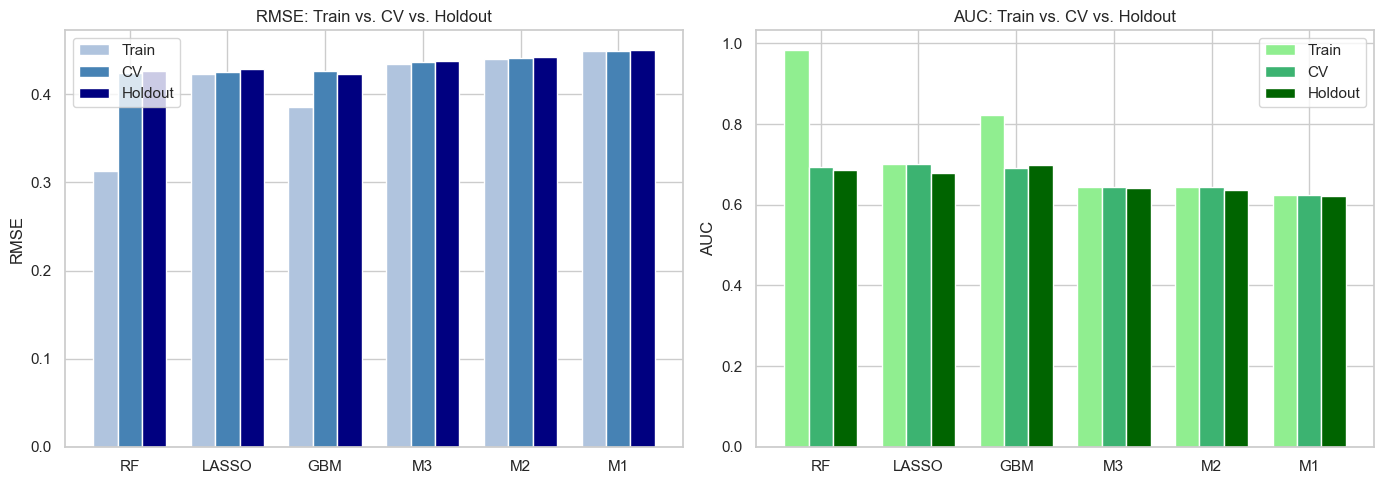

In [38]:
# horserace visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models = summary["Model"].values
x = np.arange(len(models))
width = 0.25

# RMSE panel
axes[0].bar(x - width, summary["Train RMSE"], width, label="Train", color="lightsteelblue")
axes[0].bar(x, summary["CV RMSE"], width, label="CV", color="steelblue")
axes[0].bar(x + width, summary["Holdout RMSE"], width, label="Holdout", color="navy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE: Train vs. CV vs. Holdout")
axes[0].legend()

# AUC panel
axes[1].bar(x - width, summary["Train AUC"], width, label="Train", color="lightgreen")
axes[1].bar(x, summary["CV AUC"], width, label="CV", color="mediumseagreen")
axes[1].bar(x + width, summary["Holdout AUC"], width, label="Holdout", color="darkgreen")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel("AUC")
axes[1].set_title("AUC: Train vs. CV vs. Holdout")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/horserace.png", dpi=150, bbox_inches="tight")
plt.show()

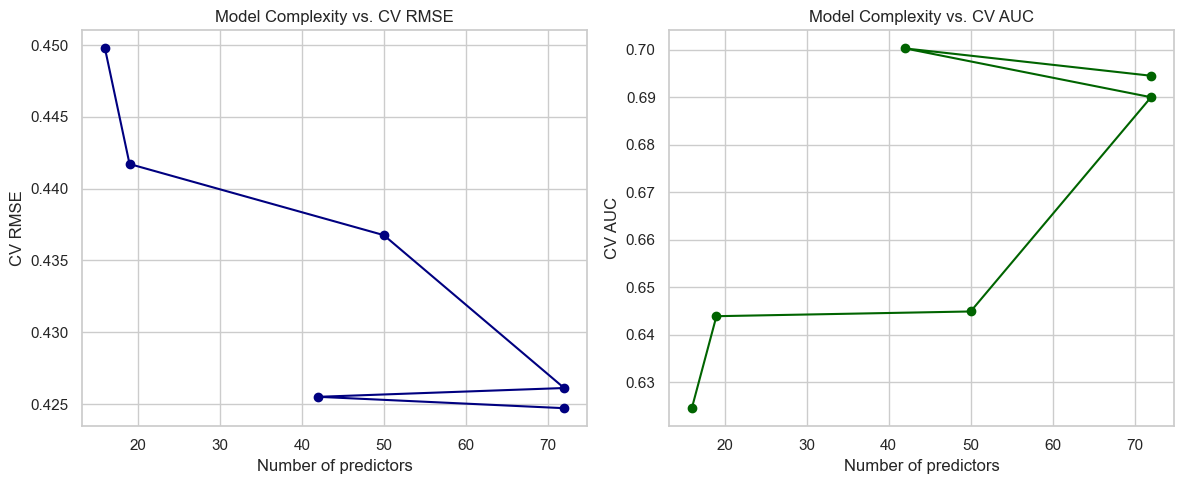

In [39]:
# model complexity vs performance plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(summary["N vars"], summary["CV RMSE"], 
             marker="o", color="navy")
axes[0].set_xlabel("Number of predictors")
axes[0].set_ylabel("CV RMSE")
axes[0].set_title("Model Complexity vs. CV RMSE")

axes[1].plot(summary["N vars"], summary["CV AUC"], 
             marker="o", color="darkgreen")
axes[1].set_xlabel("Number of predictors")
axes[1].set_ylabel("CV AUC")
axes[1].set_title("Model Complexity vs. CV AUC")

plt.tight_layout()
plt.savefig("../outputs/model_performance.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1 - Probability prediction / Classification / Discussion of results

Business context: We take the perspective of a growth-stage fund screening firms for investment. A false negative (missing a fast-growth firm) means lost upside from a high-return deal, while a false positive only wastes due diligence effort. We therefore set FN = 5 and FP = 1 in arbitrary cost units, implying that missing a true fast-grower is five times as costly as evaluating a non-grower. Our empirical fast-growth prevalence is 28.8%, which enters the ch17 threshold formula for expected loss minimization.

In [40]:
# helper functions


def sigmoid_array(x):
    return 1 / (1 + np.exp(-x))

def generate_fold_prediction(model, X, fold, param_index):
    """Extract per-fold coefficients and predict — proper out-of-fold prediction."""
    fold_coef = model.coefs_paths_[1][fold, param_index, :]
    return sigmoid_array(
        np.dot(X, np.transpose(fold_coef)[:-1]) + np.transpose(fold_coef)[-1]
    )

def create_loss_plot(all_coords, optimal_threshold, curr_exp_loss):
    all_coords_copy = all_coords.copy()
    all_coords_copy["loss"] = (
        all_coords_copy.false_pos * FP + all_coords_copy.false_neg * FN
    ) / all_coords_copy.n

    t = optimal_threshold
    l = curr_exp_loss

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(all_coords_copy["thresholds"], all_coords_copy["loss"], 
            color="navy", linewidth=1.5)
    ax.axvline(x=t, linestyle="--", color="coral")
    ax.text(t + 0.02, l, f"loss = {round(l, 3)}", fontsize=10)
    ax.text(t - 0.03, all_coords_copy["loss"].max() * 0.85,
            f"threshold = {round(t, 3)}", color="coral", rotation=90, fontsize=9)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Expected Loss")
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

def create_roc_plot_with_optimal(all_coords, optimal_threshold):
    all_coords_copy = all_coords.copy()
    all_coords_copy["sp"] = 1 - all_coords_copy.true_neg / all_coords_copy.neg
    all_coords_copy["se"] = all_coords_copy.true_pos / all_coords_copy.pos

    best_coords = all_coords_copy[all_coords_copy.thresholds == optimal_threshold]
    sp = best_coords.sp.values[0]
    se = best_coords.se.values[0]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot(all_coords_copy["sp"], all_coords_copy["se"], color="navy", linewidth=1.5)
    ax.fill_between(all_coords_copy["sp"], all_coords_copy["se"], 
                    alpha=0.2, color="steelblue")
    ax.scatter(sp, se, color="coral", s=100, zorder=5)
    ax.text(sp, se + 0.03, f"({round(sp, 2)}, {round(se, 2)})", 
            fontsize=10, ha="center")
    ax.plot([0, 1], [0, 1], linestyle=":", color="gray")
    ax.set_xlabel("False Positive Rate (1-Specificity)")
    ax.set_ylabel("True Positive Rate (Sensitivity)")
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.01)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

In [41]:
# loss function setup
# implementing the loss per the business logic described above
FP = 1
FN = 5
cost = FN / FP
prevalence = y_train.sum() / len(y_train)

print(f"FP = {FP}, FN = {FN}, cost ratio = {cost}")
print(f"Prevalence = {prevalence:.3f}")

FP = 1, FN = 5, cost ratio = 5.0
Prevalence = 0.288


In [42]:

# logit models - find optimal thresholds — logit models (ch17 pattern)

best_thresholds_cv = {}
expected_loss_cv = {}
fold5_threshold = {}
fold5_expected_loss = {}
fold5_all_coords = {}

# map model names to X matrices and c_index
logit_X_map = {
    "M1": (data_train[logit_1_vars], 0),
    "M2": (data_train[logit_2_vars], 0),
    "M3": (data_train[logit_3_vars], 0),
}

# add LASSO with its best lambda index
lasso_scores = logit_models["LASSO"].scores_[1]
best_lambda_i = np.argmax(lasso_scores.mean(axis=0))
logit_X_map["LASSO"] = (
    pd.DataFrame(
        scaler.transform(data_train[logit_4_vars]),
        columns=logit_4_vars, index=data_train.index
    ),
    best_lambda_i
)

for model_name, (X, c_index) in logit_X_map.items():
    best_thresholds = []
    expected_loss = []
    
    fold = 0
    for train_index, test_index in k.split(X, y_train):
        X_fold = X.iloc[test_index, :]
        y_fold = y_train.iloc[test_index]
        
        # proper out-of-fold prediction using fold-specific coefficients
        pred_fold = generate_fold_prediction(
            logit_models[model_name], X_fold, fold, c_index
        )
        
        fpr, tpr, thresholds = roc_curve(y_fold, pred_fold)
        
        # Optimal threshold (from ch17 formula)
        optimal_threshold = sorted(
            list(zip(
                np.abs(tpr + (1 - prevalence) / (cost * prevalence) * (1 - fpr)),
                thresholds
            )),
            key=lambda i: i[0],
            reverse=True,
        )[0][1]
        
        best_thresholds.append(optimal_threshold)
        
        threshold_prediction = np.where(pred_fold < optimal_threshold, 0, 1)
        tn, fp, fn, tp = confusion_matrix(
            y_fold, threshold_prediction, labels=[0, 1]
        ).ravel()
        curr_exp_loss = (fp * FP + fn * FN) / len(y_fold)
        expected_loss.append(curr_exp_loss)
        fold += 1
    
    best_thresholds_cv[model_name] = np.mean(best_thresholds)
    expected_loss_cv[model_name] = np.mean(expected_loss)
    
    # save fold 5 for plotting
    fold5_threshold[model_name] = optimal_threshold
    fold5_expected_loss[model_name] = curr_exp_loss
    fold5_all_coords[model_name] = pd.DataFrame({
        "false_pos": fpr * sum(y_fold == 0),
        "true_pos": tpr * sum(y_fold == 1),
        "false_neg": sum(y_fold == 1) - tpr * sum(y_fold == 1),
        "true_neg": sum(y_fold == 0) - fpr * sum(y_fold == 0),
        "pos": sum(y_fold == 1),
        "neg": sum(y_fold == 0),
        "n": len(y_fold),
        "thresholds": thresholds,
    })
    
    print(f"{model_name:>5s}: avg threshold = {best_thresholds_cv[model_name]:.3f}, "
          f"avg expected loss = {expected_loss_cv[model_name]:.4f}")

   M1: avg threshold = 0.146, avg expected loss = 0.6929
   M2: avg threshold = 0.143, avg expected loss = 0.6936
   M3: avg threshold = 0.140, avg expected loss = 0.6945
LASSO: avg threshold = 0.171, avg expected loss = 0.6594


In [43]:

# Random Forest - find optimal threshold

# RF must be refit on each fold (no coefs_paths_ available)
X_rf_train = data_train[logit_4_vars]
best_rf_params = rf_grid.best_params_

best_thresholds_rf = []
expected_loss_rf = []

fold = 0
for train_index, test_index in k.split(X_rf_train, y_train):
    X_fold = X_rf_train.iloc[test_index, :]
    y_fold = y_train.iloc[test_index]
    X_fold_train = X_rf_train.iloc[train_index, :]
    y_fold_train = y_train.iloc[train_index]
    
    # refit RF with best params on this fold's training data
    rf_fold = RandomForestClassifier(
        random_state=random_seed,
        n_estimators=500,
        oob_score=True,
        criterion="gini",
        max_features=best_rf_params["max_features"],
        min_samples_split=best_rf_params["min_samples_split"],
    )
    rf_fold.fit(X_fold_train, y_fold_train)
    pred_fold = rf_fold.predict_proba(X_fold)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_fold, pred_fold)
    
    optimal_threshold = sorted(
        list(zip(
            np.abs(tpr + (1 - prevalence) / (cost * prevalence) * (1 - fpr)),
            thresholds
        )),
        key=lambda x: x[0],
        reverse=True,
    )[0][1]
    
    best_thresholds_rf.append(optimal_threshold)
    threshold_prediction = np.where(pred_fold < optimal_threshold, 0, 1)
    tn, fp, fn, tp = confusion_matrix(
        y_fold, threshold_prediction, labels=[0, 1]
    ).ravel()
    curr_exp_loss = (fp * FP + fn * FN) / len(y_fold)
    expected_loss_rf.append(curr_exp_loss)
    fold += 1

best_thresholds_cv["RF"] = np.mean(best_thresholds_rf)
expected_loss_cv["RF"] = np.mean(expected_loss_rf)

# save fold 5 for plotting
fold5_threshold["RF"] = optimal_threshold
fold5_expected_loss["RF"] = curr_exp_loss
fold5_all_coords["RF"] = pd.DataFrame({
    "false_pos": fpr * sum(y_fold == 0),
    "true_pos": tpr * sum(y_fold == 1),
    "false_neg": sum(y_fold == 1) - tpr * sum(y_fold == 1),
    "true_neg": sum(y_fold == 0) - fpr * sum(y_fold == 0),
    "pos": sum(y_fold == 1),
    "neg": sum(y_fold == 0),
    "n": len(y_fold),
    "thresholds": thresholds,
})

print(f"   RF: avg threshold = {best_thresholds_cv['RF']:.3f}, "
      f"avg expected loss = {expected_loss_cv['RF']:.4f}")

   RF: avg threshold = 0.158, avg expected loss = 0.6606


In [44]:

# GBM - find optimal threshold refit per fold like RF

X_gbm_train = data_train[logit_4_vars]
best_gbm_params = gbm_search.best_params_

best_thresholds_gbm = []
expected_loss_gbm = []

fold = 0
for train_index, test_index in k.split(X_gbm_train, y_train):
    X_fold = X_gbm_train.iloc[test_index, :]
    y_fold = y_train.iloc[test_index]
    X_fold_train = X_gbm_train.iloc[train_index, :]
    y_fold_train = y_train.iloc[train_index]
    
    gbm_fold = GradientBoostingClassifier(
        random_state=random_seed,
        n_estimators=500,
        max_depth=best_gbm_params["max_depth"],
        learning_rate=best_gbm_params["learning_rate"],
        min_samples_split=best_gbm_params["min_samples_split"],
    )
    gbm_fold.fit(X_fold_train, y_fold_train)
    pred_fold = gbm_fold.predict_proba(X_fold)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_fold, pred_fold)
    
    optimal_threshold = sorted(
        list(zip(
            np.abs(tpr + (1 - prevalence) / (cost * prevalence) * (1 - fpr)),
            thresholds
        )),
        key=lambda x: x[0],
        reverse=True,
    )[0][1]
    
    best_thresholds_gbm.append(optimal_threshold)
    threshold_prediction = np.where(pred_fold < optimal_threshold, 0, 1)
    tn, fp, fn, tp = confusion_matrix(
        y_fold, threshold_prediction, labels=[0, 1]
    ).ravel()
    curr_exp_loss = (fp * FP + fn * FN) / len(y_fold)
    expected_loss_gbm.append(curr_exp_loss)
    fold += 1

best_thresholds_cv["GBM"] = np.mean(best_thresholds_gbm)
expected_loss_cv["GBM"] = np.mean(expected_loss_gbm)

fold5_threshold["GBM"] = optimal_threshold
fold5_expected_loss["GBM"] = curr_exp_loss
fold5_all_coords["GBM"] = pd.DataFrame({
    "false_pos": fpr * sum(y_fold == 0),
    "true_pos": tpr * sum(y_fold == 1),
    "false_neg": sum(y_fold == 1) - tpr * sum(y_fold == 1),
    "true_neg": sum(y_fold == 0) - fpr * sum(y_fold == 0),
    "pos": sum(y_fold == 1),
    "neg": sum(y_fold == 0),
    "n": len(y_fold),
    "thresholds": thresholds,
})

print(f"  GBM: avg threshold = {best_thresholds_cv['GBM']:.3f}, "
      f"avg expected loss = {expected_loss_cv['GBM']:.4f}")

  GBM: avg threshold = 0.140, avg expected loss = 0.6603


In [45]:

# classification summary table
summary["CV threshold"] = summary["Model"].map(best_thresholds_cv)
summary["CV expected loss"] = summary["Model"].map(expected_loss_cv)

(summary.set_index("Model").style
    .format({
        "N vars": "{:d}",
        "Train RMSE": "{:.4f}", "CV RMSE": "{:.4f}", "Holdout RMSE": "{:.4f}",
        "Train AUC": "{:.4f}", "CV AUC": "{:.4f}", "Holdout AUC": "{:.4f}",
        "CV threshold": "{:.3f}",
        "CV expected loss": "{:.4f}",
    })
    .set_caption(f"Model Summary with Loss Function (FP={FP}, FN={FN})")
    .background_gradient(subset=["CV RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["CV AUC", "Holdout AUC"], cmap="RdYlGn")
    .background_gradient(subset=["CV expected loss"], cmap="RdYlGn_r")
)

,N vars,Train RMSE,CV RMSE,Holdout RMSE,Train AUC,CV AUC,Holdout AUC,CV threshold,CV expected loss
Model,,,,,,,,,
RF,72,0.3132,0.4247,0.4261,0.9831,0.6946,0.6867,0.158,0.6606
LASSO,42,0.4236,0.4255,0.4290,0.7003,0.7003,0.6791,0.171,0.6594
GBM,72,0.3860,0.4261,0.4231,0.8229,0.6900,0.6988,0.140,0.6603
M3,50,0.4343,0.4368,0.4377,0.6450,0.6449,0.6408,0.140,0.6945
M2,19,0.4405,0.4417,0.4420,0.6439,0.6439,0.6375,0.143,0.6936
M1,16,0.4487,0.4498,0.4502,0.6245,0.6246,0.6209,0.146,0.6929


Best model by expected loss: LASSO


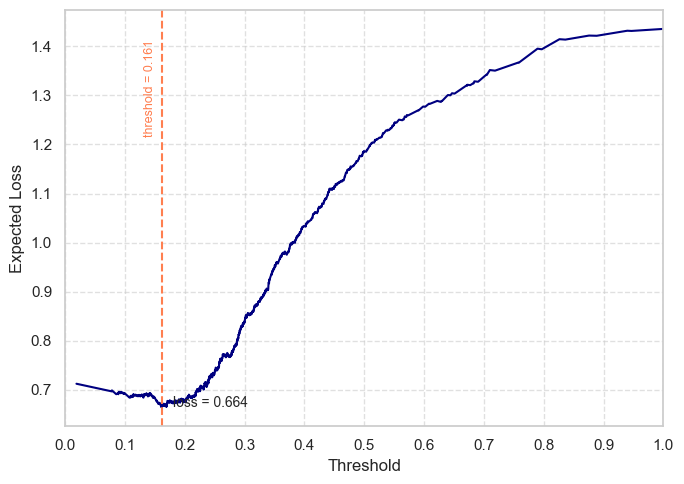

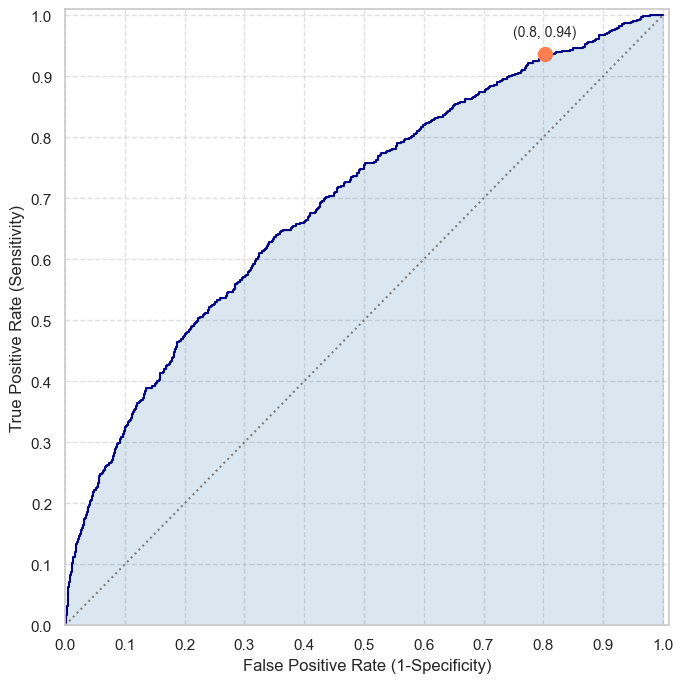

In [47]:

# loss and ROC plots (fold 5, best model)

# best_model_name = summary.sort_values("CV expected loss").iloc[0]["Model"]
print(f"Best model by expected loss: {best_model_name}")

create_loss_plot(
    fold5_all_coords[best_model_name],
    fold5_threshold[best_model_name],
    fold5_expected_loss[best_model_name]
)

create_roc_plot_with_optimal(
    fold5_all_coords[best_model_name],
    fold5_threshold[best_model_name]
)

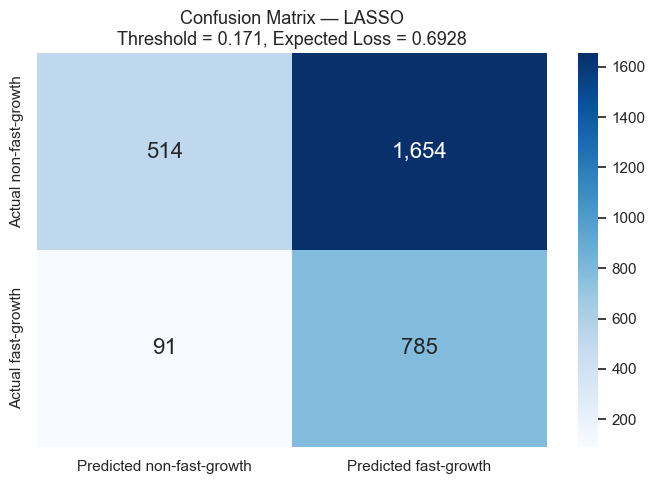

Precision: 0.322
Recall:    0.896
Accuracy:  0.427


In [61]:

# holdout evaluation — best model

best_model = logit_models[best_model_name]
best_threshold = best_thresholds_cv[best_model_name]

# Get holdout predictions
if best_model_name in ["M1", "M2", "M3"]:
    var_map = {"M1": logit_1_vars, "M2": logit_2_vars, "M3": logit_3_vars}
    X_ho = data_holdout[var_map[best_model_name]]
elif best_model_name == "LASSO":
    X_ho = pd.DataFrame(
        scaler.transform(data_holdout[logit_4_vars]),
        columns=logit_4_vars, index=data_holdout.index
    )
elif best_model_name == "RF":
    X_ho = data_holdout[logit_4_vars]
elif best_model_name == "GBM":
    X_ho = data_holdout[logit_4_vars]

pred_holdout = best_model.predict_proba(X_ho)[:, 1]
holdout_prediction = np.where(pred_holdout < best_threshold, 0, 1)

# confusion matrix
cm = confusion_matrix(y_holdout, holdout_prediction, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
expected_loss_holdout = (fp * FP + fn * FN) / len(y_holdout)
cm_df = pd.DataFrame(
    cm,
    index=["Actual non-fast-growth", "Actual fast-growth"],
    columns=["Predicted non-fast-growth", "Predicted fast-growth"],
)

cm_df

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues",
            annot_kws={"size": 16}, ax=ax)
ax.set_title(f"Confusion Matrix — {best_model_name}\n"
             f"Threshold = {best_threshold:.3f}, "
             f"Expected Loss = {expected_loss_holdout:.4f}", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Precision: {cm[1,1] / (cm[1,1] + cm[0,1]):.3f}")
print(f"Recall:    {cm[1,1] / (cm[1,1] + cm[1,0]):.3f}")
print(f"Accuracy:  {(cm[0,0] + cm[1,1]) / cm.sum():.3f}")

## Interpretation of Confusion Matrix (LASSO, Holdout)

With the asymmetric loss function (FP=$1, FN=$5) and an optimal threshold of 0.171:

- **True Positives (785):** Correctly identified fast-growth firms, so investment opportunities captured.
- **False Positives (1,654):** Non-growers incorrectly flagged, so wasted due diligence at $1 each.
- **False Negatives (91):** Missed fast-growth firms, so lost opportunities at $5 each.
- **True Negatives (514):** Correctly screened out non-growers.

The model deliberately trades precision (32%) for recall (89.6%) because our loss function penalizes missed fast-growers 5× more than false alarms. The total expected loss on holdout is 0.693 per firm. Of the 876 actual fast-growth firms, we catch 785 (90%), which is a useful screening rate for an investment fund willing to absorb due diligence costs on false positives.

The 1,654 false positives may seem high, and this is a direct consequence of the 5:1 cost ratio. A lower FN/FP ratio (e.g. 2:1) would raise the threshold and reduce false alarms, but at the cost of missing more fast-growth firms. The appropriate ratio is ultimately a business decision depending on how costly missed opportunities are relative to screening costs.  

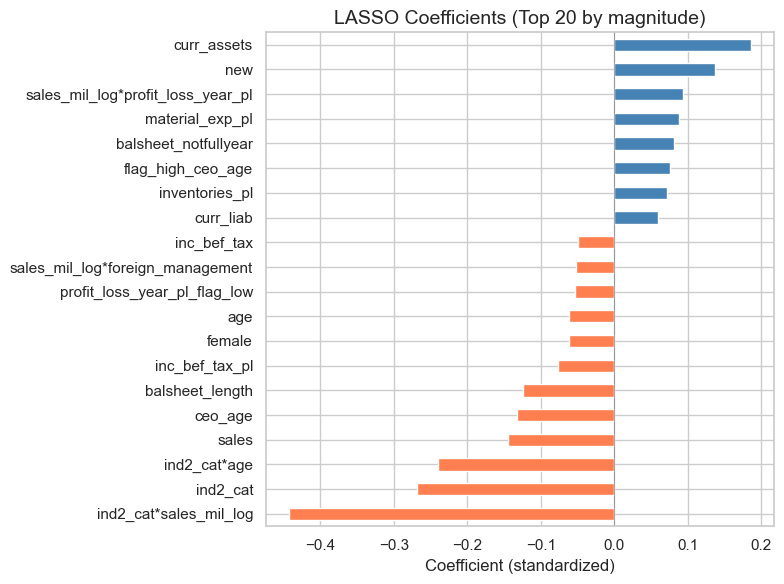

In [56]:
# LASSO coefficient importance - Top 20
coefs = pd.Series(
    lasso_model.coef_[0], index=logit_4_vars
)
top20 = coefs.abs().sort_values(ascending=False).head(20)
plot_coefs = coefs[top20.index].sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["coral" if v < 0 else "steelblue" for v in plot_coefs]
plot_coefs.plot.barh(ax=ax, color=colors)
ax.set_title("LASSO Coefficients (Top 20 by magnitude)", fontsize=14)
ax.set_xlabel("Coefficient (standardized)")
ax.axvline(x=0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Discussion of Results

Our best model is LASSO, which achieves the lowest CV expected loss (0.659) and the highest CV AUC (0.700) while showing zero overfitting — Train and CV AUC are virtually identical. On holdout it delivers AUC of 0.68 and expected loss of 0.693.

**Why LASSO?** Beyond statistical performance, LASSO offers full interpretability. Its coefficients reveal which variables drive predictions and in which direction. This is not something tree-based models are able to provide. LASSO also performed automatic feature selection, shrinking 72 input variables down to 42 non-zero coefficients.

**Classification trade-offs.** With FN costing 5× FP, the optimal threshold drops to 0.171. This is below the 29% base rate for fast_growth. This yields recall of 90% and precision of 32%: we catch most fast-growth firms at the cost of false alarms. From ~3,000 holdout firms the model screens out ~500 unlikely growers while missing 91 true fast-growth firms.

**Model comparison.** RF and GBM achieve marginally better RMSE but both overfit substantially (RF Train AUC 0.98, GBM 0.82 vs CV ~0.69). Their slight edge in expected loss (0.660 vs 0.659) does not justify the loss of interpretability and stability.

**Key predictors.** LASSO coefficients show current assets and the "new firm" flag as the strongest positive predictors — younger firms with more liquid assets are more likely to grow fast. The industry-sales interaction (ind2_cat*sales_mil_log) has the largest negative coefficient, suggesting that the relationship between size and growth varies strongly across sectors. Sales level, CEO age, and balance sheet length also carry negative coefficients, consistent with the intuition that larger, older, more established firms tend to grow more slowly.

**Limitations.** AUC of 0.70 reflects moderate discriminatory power. Firm growth depends heavily on unobservables (market opportunities, innovation, management quality) that financial statements cannot capture.

## Task 2 - Industry Categories

In [57]:

# industry Comparison
# Split into manufacturing (NACE 10-33) and services (55-56)

data_manuf = data[data["manufacturing_flg"] == 1].copy()
data_serv = data[data["services_flg"] == 1].copy()

print(f"Manufacturing: {len(data_manuf):,} firms, "
      f"fast-growth rate: {data_manuf['fast_growth'].mean():.1%}")
print(f"Services:      {len(data_serv):,} firms, "
      f"fast-growth rate: {data_serv['fast_growth'].mean():.1%}")

Manufacturing: 4,992 firms, fast-growth rate: 29.0%
Services:      10,228 firms, fast-growth rate: 28.7%


In [58]:
# full LASSO pipeline for both industries
industry_results = {}

for label, data_ind in [("Manufacturing", data_manuf), ("Services", data_serv)]:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    
    # Train/holdout split
    d_train, d_holdout = train_test_split(
        data_ind, test_size=0.2, random_state=random_seed,
        stratify=data_ind["fast_growth"]
    )
    y_tr = d_train["fast_growth"].astype(int)
    y_ho = d_holdout["fast_growth"].astype(int)
    
    # Standardize
    sc = StandardScaler()
    X_tr = pd.DataFrame(
        sc.fit_transform(d_train[logit_4_vars]),
        columns=logit_4_vars, index=d_train.index
    )
    X_ho = pd.DataFrame(
        sc.transform(d_holdout[logit_4_vars]),
        columns=logit_4_vars, index=d_holdout.index
    )
    
    # Fit LASSO
    n_obs_ind = X_tr.shape[0] * 4 / 5
    lambdas_ind = list(10 ** np.arange(-1, -4.01, -1/3))
    C_values_ind = [1 / (l * n_obs_ind) for l in lambdas_ind]
    
    lasso_ind = LogisticRegressionCV(
        Cs=C_values_ind, penalty="l1", cv=k, refit=True,
        scoring="neg_brier_score", solver="liblinear",
        random_state=random_seed
    )
    lasso_ind.fit(X_tr, y_tr)
    
    # CV RMSE and AUC
    scores = lasso_ind.scores_[1]
    best_c = np.argmax(scores.mean(axis=0))
    cv_rmse = np.mean(np.sqrt(-scores[:, best_c]))
    
    auc_folds = []
    for train_idx, val_idx in k.split(X_tr, y_tr):
        pred = lasso_ind.predict_proba(X_tr.iloc[val_idx])[:, 1]
        auc_folds.append(roc_auc_score(y_tr.iloc[val_idx], pred))
    cv_auc = np.mean(auc_folds)
    
    # Optimal threshold via loss function (ch17 pattern)
    prevalence_ind = y_tr.mean()
    best_thresholds = []
    expected_losses = []
    
    fold = 0
    for train_idx, val_idx in k.split(X_tr, y_tr):
        X_fold = X_tr.iloc[val_idx]
        y_fold = y_tr.iloc[val_idx]
        pred_fold = generate_fold_prediction(lasso_ind, X_fold, fold, best_c)
        
        fpr, tpr, thresholds = roc_curve(y_fold, pred_fold)
        optimal_t = sorted(
            list(zip(
                np.abs(tpr + (1 - prevalence_ind) / (cost * prevalence_ind) * (1 - fpr)),
                thresholds
            )),
            key=lambda i: i[0], reverse=True,
        )[0][1]
        
        best_thresholds.append(optimal_t)
        y_pred = np.where(pred_fold < optimal_t, 0, 1)
        tn, fp, fn, tp = confusion_matrix(y_fold, y_pred, labels=[0, 1]).ravel()
        expected_losses.append((fp * FP + fn * FN) / len(y_fold))
        fold += 1
    
    avg_threshold = np.mean(best_thresholds)
    avg_loss = np.mean(expected_losses)
    
    # Holdout evaluation
    pred_ho = lasso_ind.predict_proba(X_ho)[:, 1]
    ho_pred = np.where(pred_ho < avg_threshold, 0, 1)
    tn, fp, fn, tp = confusion_matrix(y_ho, ho_pred, labels=[0, 1]).ravel()
    ho_loss = (fp * FP + fn * FN) / len(y_ho)
    ho_rmse = np.sqrt(mean_squared_error(y_ho, pred_ho))
    ho_auc = roc_auc_score(y_ho, pred_ho)
    
    n_nonzero = int(np.sum(lasso_ind.coef_[0] != 0))
    
    industry_results[label] = {
        "N firms": len(data_ind),
        "Fast-growth rate": f"{data_ind['fast_growth'].mean():.1%}",
        "N vars (non-zero)": n_nonzero,
        "CV RMSE": cv_rmse,
        "CV AUC": cv_auc,
        "CV threshold": avg_threshold,
        "CV expected loss": avg_loss,
        "Holdout RMSE": ho_rmse,
        "Holdout AUC": ho_auc,
        "Holdout expected loss": ho_loss,
        "Holdout TP": tp,
        "Holdout FP": fp,
        "Holdout FN": fn,
        "Holdout TN": tn,
    }
    
    print(f"  N = {len(data_ind):,}, fast-growth = {data_ind['fast_growth'].mean():.1%}")
    print(f"  Non-zero vars: {n_nonzero}")
    print(f"  CV RMSE: {cv_rmse:.4f}, CV AUC: {cv_auc:.4f}")
    print(f"  Threshold: {avg_threshold:.3f}, CV loss: {avg_loss:.4f}")
    print(f"  Holdout RMSE: {ho_rmse:.4f}, AUC: {ho_auc:.4f}, loss: {ho_loss:.4f}")


  Manufacturing
  N = 4,992, fast-growth = 29.0%
  Non-zero vars: 30
  CV RMSE: 0.4413, CV AUC: 0.6524
  Threshold: 0.164, CV loss: 0.6827
  Holdout RMSE: 0.4370, AUC: 0.6520, loss: 0.6937

  Services
  N = 10,228, fast-growth = 28.7%
  Non-zero vars: 44
  CV RMSE: 0.4195, CV AUC: 0.7202
  Threshold: 0.166, CV loss: 0.6439
  Holdout RMSE: 0.4138, AUC: 0.7271, loss: 0.6432


In [59]:
# comparison table
comp = pd.DataFrame(industry_results).T
comp_display = comp[["N firms", "Fast-growth rate", "N vars (non-zero)",
                      "CV RMSE", "CV AUC", "CV threshold", 
                      "CV expected loss", "Holdout AUC", "Holdout expected loss"]]

(comp_display.style
    .format({
        "N firms": "{:,}",
        "N vars (non-zero)": "{:d}",
        "CV RMSE": "{:.4f}", "CV AUC": "{:.4f}",
        "CV threshold": "{:.3f}",
        "CV expected loss": "{:.4f}",
        "Holdout AUC": "{:.4f}",
        "Holdout expected loss": "{:.4f}",
    })
    .set_caption("Task 2: Industry Comparison (LASSO, FP=1, FN=5)")
    .background_gradient(subset=["CV RMSE", "CV expected loss", "Holdout expected loss"], cmap="RdYlGn_r")
    .background_gradient(subset=["CV AUC", "Holdout AUC"], cmap="RdYlGn")
)

,N firms,Fast-growth rate,N vars (non-zero),CV RMSE,CV AUC,CV threshold,CV expected loss,Holdout AUC,Holdout expected loss
Manufacturing,"4,992",29.0%,30,0.4413,0.6524,0.164,0.6827,0.6520,0.6937
Services,"10,228",28.7%,44,0.4195,0.7202,0.166,0.6439,0.7271,0.6432


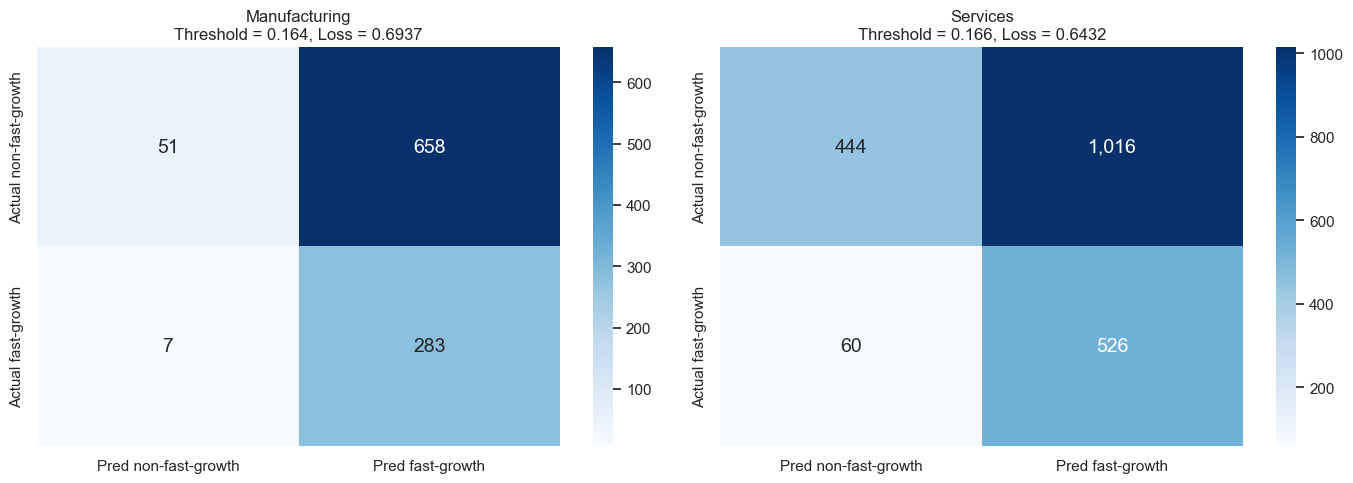

In [60]:
# confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label in zip(axes, ["Manufacturing", "Services"]):
    r = industry_results[label]
    cm = np.array([[r["Holdout TN"], r["Holdout FP"]], 
                   [r["Holdout FN"], r["Holdout TP"]]])
    cm_df = pd.DataFrame(
        cm,
        index=["Actual non-fast-growth", "Actual fast-growth"],
        columns=["Pred non-fast-growth", "Pred fast-growth"],
    )
    sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues",
                annot_kws={"size": 14}, ax=ax)
    ax.set_title(f"{label}\nThreshold = {r['CV threshold']:.3f}, "
                 f"Loss = {r['Holdout expected loss']:.4f}", fontsize=12)

plt.tight_layout()
plt.savefig("../outputs/confusion_industry.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 2: Industry Comparison

LASSO performs notably better on services (CV AUC 0.72, holdout loss 0.64) than manufacturing (CV AUC 0.65, holdout loss 0.69). The services sample is twice as large (10,228 vs 4,992) and retains more non-zero LASSO coefficients (44 vs 30), suggesting richer signal in the data.

Thresholds are similar (~0.165 for both), but the confusion matrices reveal different screening profiles. Manufacturing screens out only 51 of 999 holdout firms — the model flags nearly everyone. Services provides more useful filtering, eliminating ~444 firms while missing 60 fast-growers. In practice, LASSO is a useful screening tool for services firms but offers limited discriminatory value for manufacturing, where growth likely depends on sector-specific factors not captured by general financial ratios.